In [1]:
import argopy
from argopy import DataFetcher as ArgoDataFetcher
import numpy as np
import pandas as pd
from tqdm.auto import tqdm, trange
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import generate_knots, make_lsq_spline
from scipy.ndimage import gaussian_filter1d
from scipy import stats as dists
from scipy.signal import savgol_filter
import ruptures as rpt

/home/jcherry/Documents/storage/git/argo-data-interpolation/.venv/bin/python: No module named pip


In [2]:
box = [
    -75, -45, ## Longitude min/max
    20, 30, ## Latitude min/max
    0, 3000, ## Pressure/depth min/max
    '2011-01', '2011-06', ## Datetime min/max
]
f = ArgoDataFetcher().region(box).load()
data = f.data.to_dataframe()

In [3]:
group_col = 'PLATFORM_CYCLE'
group_fields = ['PLATFORM_NUMBER', 'CYCLE_NUMBER']
cycle_fields = ['LATITUDE', 'LONGITUDE', 'TIME']
reading_fields = ['PRES', 'PRES_ERROR', 'PSAL', 'PSAL_ERROR', 'TEMP', 'TEMP_ERROR']

In [4]:
cycles = data[group_fields + cycle_fields].drop_duplicates().sort_values(group_fields)
cycles.index = (cycles[group_fields[0]].astype(str) + '-' + cycles[group_fields[1]].astype(str)).rename('PLATFORM_CYCLE')

In [5]:
readings = data[group_fields + reading_fields].drop_duplicates().sort_values([*group_fields, 'PRES']).reset_index(drop=True)
readings.insert(0, group_col, readings[group_fields[0]].astype(str) + '-' + readings[group_fields[1]].astype(str))
readings = readings.drop(columns=group_fields)

In [6]:
pres_error = 2.4
temp_error = 0.002
dbar_to_meter = savgol_filter

In [7]:
for cycle_number, cycle_data in readings.groupby('PLATFORM_CYCLE'):
    x = cycle_data['PRES']
    y = cycle_data.set_index('PRES')['TEMP']

In [8]:
cycle_number = '6901052-1'
cycle_data = readings.loc[readings['PLATFORM_CYCLE'] == cycle_number]

In [16]:
double_diff = (cycle_data['TEMP'] / cycle_data['PRES']).diff().diff()
double_diff.index = cycle_data['PRES']
double_diff.name = 'double_diff'

In [17]:
double_diff

PRES
5.300000            NaN
10.800000           NaN
15.500000      1.761215
20.000000      0.322953
25.600000      0.141439
                 ...   
1800.400024   -0.000022
1850.599976    0.000004
1900.000000    0.000003
1950.599976    0.000016
1998.400024    0.000012
Name: double_diff, Length: 78, dtype: float32

In [375]:
pres_delta = pd.concat([
    cycle_data['PRES'],
    cycle_data['PRES'].rename('pres_delta').diff(),
], axis=1).set_index('PRES')['pres_delta'].dropna()

In [376]:
algo = rpt.Binseg(model='l2').fit(pres_delta.values)
breaks = algo.predict(n_bkps=3)

In [380]:
pres_delta

PRES
10.800000       5.500000
15.500000       4.700000
20.000000       4.500000
25.600000       5.600000
30.000000       4.400000
                 ...    
1800.400024    49.900024
1850.599976    50.199951
1900.000000    49.400024
1950.599976    50.599976
1998.400024    47.800049
Name: pres_delta, Length: 77, dtype: float32

In [379]:
pres_delta.iloc[40]

np.float32(25.300018)

In [337]:
x = cycle_data['PRES']
y = cycle_data.set_index('PRES')['TEMP']

In [321]:
deltas = pd.Series(y.diff().values / x.diff().values, name='delta', index=x)

In [328]:
noise_stdev = (deltas - deltas.median()).abs().median()

In [301]:
sigmas = np.array([5, 10, 15, 18, 20, 22, 25])[np.newaxis, np.newaxis, :]
pressure_input = x.values[:, np.newaxis, np.newaxis]
pressure_cross = x.values[np.newaxis, :, np.newaxis]

dist = dists.norm(pressure_input, sigmas)
pres_weights = dist.pdf(pressure_cross)
pres_weights /= pres_weights.sum(axis=1, keepdims=True)

In [302]:
smooth_temp = pd.DataFrame(np.einsum('ijk,j->ik', pres_weights, cycle_data['TEMP'].values), index=cycle_data['PRES'], columns=sigmas[0,0,:])

In [308]:
knot_counts = {}
splines = {}
for sigma_val, sigma_smooth in smooth_temp.items():
    error_thresh = ((y - sigma_smooth).std() ** 2) * len(sigma_smooth)
    *_, knots = generate_knots(x=x, y=sigma_smooth, s=error_thresh)
    knot_counts[sigma_val] = len(knots) - 8
    splines[sigma_val] = make_lsq_spline(x, y, t=knots)
sigma_splines = pd.concat([
    pd.Series(knot_counts, name='knots'),
    pd.Series(splines, name='splines'),
], axis=1)

In [312]:
sigma_splines['knots'].diff().diff()

5     NaN
10    NaN
15    5.0
18    4.0
20    1.0
22   -1.0
25    1.0
Name: knots, dtype: float64

<Axes: xlabel='PRES', ylabel='TEMP'>

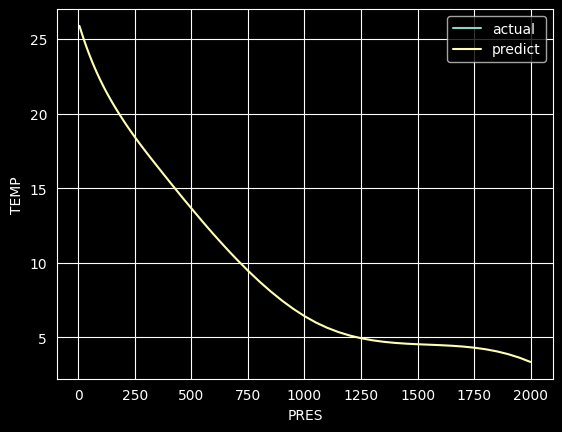

In [292]:
y_1 = splines(x)
sns.lineplot(x=x, y=y, label='actual')
# sns.lineplot(x=x, y=smooth_temp, label='smooth')
sns.lineplot(x=x, y=y_1, label='predict')